In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [63]:
# Paths to your dataset
train_dir = "dataset/split/train"
val_dir = "dataset/split/val"
test_dir = "dataset/split/test"

# Parameters
img_height, img_width = 128, 128  # Resize all images to 128x128
batch_size = 250

# Data Augmentation and Data Generators
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values to [0, 1]
    rotation_range=20,  # Augmentations
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary", shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary", shuffle=False
)



Found 3793 images belonging to 2 classes.
Found 1082 images belonging to 2 classes.


Epoch 1/30
16/16 [==============================] - 30s 2s/step - loss: 0.7053 - accuracy: 0.4052 - val_loss: 0.8077 - val_accuracy: 0.3725
Epoch 2/30
16/16 [==============================] - 27s 2s/step - loss: 0.4090 - accuracy: 0.7271 - val_loss: 0.3222 - val_accuracy: 0.8900
Epoch 3/30
16/16 [==============================] - 28s 2s/step - loss: 0.4020 - accuracy: 0.8104 - val_loss: 0.3926 - val_accuracy: 0.8734
Epoch 4/30
16/16 [==============================] - 27s 2s/step - loss: 0.3409 - accuracy: 0.8408 - val_loss: 0.3941 - val_accuracy: 0.8641
Epoch 5/30
16/16 [==============================] - 470s 31s/step - loss: 0.3131 - accuracy: 0.8537 - val_loss: 0.5949 - val_accuracy: 0.7458
Epoch 6/30
16/16 [==============================] - 28s 2s/step - loss: 0.3072 - accuracy: 0.8471 - val_loss: 0.3528 - val_accuracy: 0.8669
Epoch 7/30
16/16 [==============================] - 27s 2s/step - loss: 0.2930 - accuracy: 0.8460 - val_loss: 0.2948 - val_accuracy: 0.8882
Epoch 8/30
16/16 [

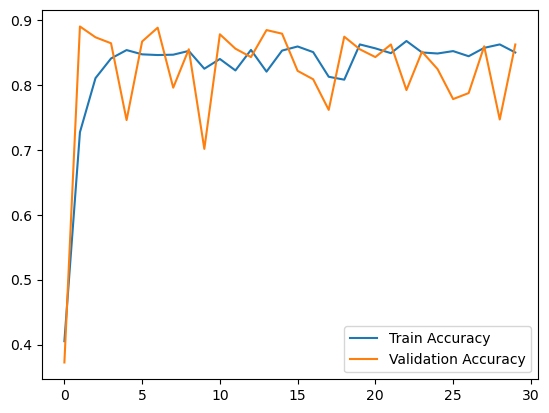

/Users/solozobovavaleria/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Found 551 images belonging to 2 classes.
3/3 [==============================] - 1s 199ms/step
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.83      0.90       360
     Class 1       0.76      0.98      0.86       191

    accuracy                           0.89       551
   macro avg       0.87      0.91      0.88       551
weighted avg       0.91      0.89      0.89       551



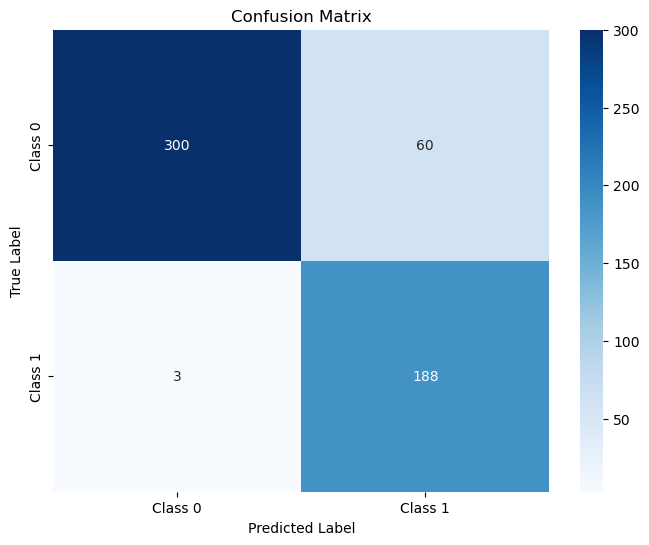

In [64]:
# Build the CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")  # Binary classification
])

#class_weights = {0: 1.0, 1: len(y_test) / sum(y_test == 1)}

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
class_weights={0:0.5, 1:2}
# Train the Model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30, class_weight=class_weights
)

# Plot Training and Validation Accuracy
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.show()

# Save the Model
model.save("cnn_model.h5")

# Assuming test_generator is defined like this:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,  # Path to your test data folder
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # Use 'categorical' for multi-class problems
    shuffle=False  # Keep order consistent for metrics calculation
)

# Extract true labels
y_test = test_generator.classes  # This gives you the ground truth l
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_generator)

# Predict on the test set
y_pred = model.predict(test_generator)  # Predicted probabilities
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()  # Convert probabilities to binary classes

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Class 0', 'Class 1']))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [51]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(img_height, img_width, 3))
base_model.trainable = False  # Freeze the base model

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Train as before

Epoch 1/10
38/38 [==============================] - 61s 2s/step - loss: 0.6796 - accuracy: 0.6264 - val_loss: 0.6406 - val_accuracy: 0.6553
Epoch 2/10
38/38 [==============================] - 52s 1s/step - loss: 0.6498 - accuracy: 0.6525 - val_loss: 0.6359 - val_accuracy: 0.6553
Epoch 3/10
38/38 [==============================] - 77s 2s/step - loss: 0.6432 - accuracy: 0.6546 - val_loss: 0.6300 - val_accuracy: 0.6553
Epoch 4/10
38/38 [==============================] - 67s 2s/step - loss: 0.6373 - accuracy: 0.6552 - val_loss: 0.6232 - val_accuracy: 0.6553
Epoch 5/10
38/38 [==============================] - 62s 2s/step - loss: 0.6326 - accuracy: 0.6557 - val_loss: 0.6184 - val_accuracy: 0.6553
Epoch 6/10
38/38 [==============================] - 66s 2s/step - loss: 0.6241 - accuracy: 0.6565 - val_loss: 0.6099 - val_accuracy: 0.6562
Epoch 7/10
38/38 [==============================] - 56s 1s/step - loss: 0.6215 - accuracy: 0.6588 - val_loss: 0.6026 - val_accuracy: 0.6562
Epoch 8/10
38/38 [==

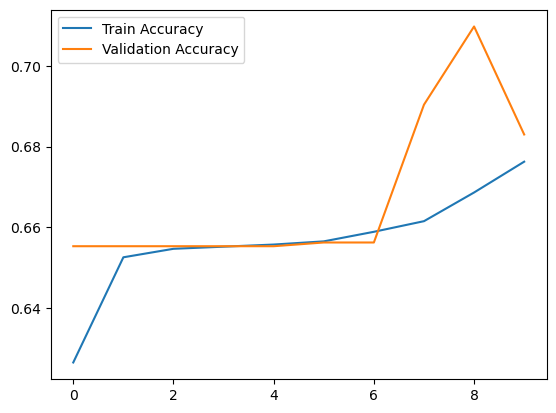

/Users/solozobovavaleria/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Found 551 images belonging to 2 classes.
6/6 [==============================] - 8s 1s/step - loss: 0.5832 - accuracy: 0.6679
Test Accuracy: 66.79%


In [52]:
# Train the Model
history_2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# Plot Training and Validation Accuracy
plt.plot(history_2.history["accuracy"], label="Train Accuracy")
plt.plot(history_2.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.show()

# Save the Model
model.save("cnn_model_resnet50.h5")

test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale, no augmentation
# Evaluate on Test Data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary", shuffle=False
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

In [65]:
test_datagen = ImageDataGenerator(rescale=1./255)  # Only rescale, no augmentation

test_generator = test_datagen.flow_from_directory(
    test_dir,  # Path to your test dataset folder
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  # Use 'categorical' for multi-class problems
    shuffle=False  # Keep order for metrics calculation
)

Found 551 images belonging to 2 classes.


In [53]:

test_loss, test_accuracy = model.evaluate(test_generator)
y_pred = model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype("int32")  # Convert probabilities to binary classes
# Extract true labels
y_test = test_generator.classes  # This gives you the ground truth
# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Class 0', 'Class 1']))

6/6 [==============================] - 6s 943ms/step
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.67      0.99      0.80       360
     Class 1       0.75      0.06      0.12       191

    accuracy                           0.67       551
   macro avg       0.71      0.53      0.46       551
weighted avg       0.69      0.67      0.56       551

